## International shipping tonne-km by R10 region

Extracts raw and preprocessed international shipping tonne-km from
`trp_frgt_Tkm.out` (see `extract_international_shipping_tkm.py`), aggregates
the 26 IMAGE regions to 10 R10 macro-regions, and plots each region's trend
1971-2100 as small multiples with a shared x- and y-axis, so both trend shape
and magnitude are comparable across regions.

In [4]:
import sys
import pandas as pd

sys.path.insert(0, ".")  # so we can import the sibling script in examples/
from extract_international_shipping_tkm import (
    get_raw_international_shipping,
    get_preprocessed_international_shipping,
)

raw = get_raw_international_shipping()
preprocessed = get_preprocessed_international_shipping()
tkm = pd.concat([raw, preprocessed], ignore_index=True).rename(columns={"time": "year"})

# R10 macro-region mapping for the 26 IMAGE regions (standard IMAGE/IIASA R10 grouping)
R10_MAPPING = {
    "CAN": "North America", "USA": "North America",
    "MEX": "Latin America", "RCAM": "Latin America", "BRA": "Latin America", "RSAM": "Latin America",
    "NAF": "Africa", "WAF": "Africa", "EAF": "Africa", "SAF": "Africa", "RSAF": "Africa",
    "WEU": "Europe", "CEU": "Europe",
    "TUR": "Reforming Economies", "UKR": "Reforming Economies", "STAN": "Reforming Economies", "RUS": "Reforming Economies",
    "ME": "Middle East",
    "INDIA": "India+", "RSAS": "India+",
    "CHN": "China+",
    "SEAS": "Rest of Asia", "INDO": "Rest of Asia",
    "JAP": "Pacific OECD", "KOR": "Pacific OECD", "OCE": "Pacific OECD",
}

# Region 27 (unused/empty) and 28 (World total, = sum of regions 1-26) are excluded
# from the R10 aggregation to avoid double-counting.
r10 = tkm[tkm["region"] <= 26].copy()
r10["r10_region"] = r10["region_name"].map(R10_MAPPING)

r10_preprocessed = (
    r10[r10["source"] == "preprocessed"]
    .groupby(["year", "r10_region"])["ton_km_mega"]
    .sum()
    .unstack("r10_region")
)
# order panels by final-year (2100) value, highest first
region_order = r10_preprocessed.loc[2100].sort_values(ascending=False).index.tolist()
r10_preprocessed = r10_preprocessed[region_order]
r10_preprocessed.tail()

r10_region,Europe,Africa,Rest of Asia,North America,China+,India+,Latin America,Pacific OECD,Middle East,Reforming Economies
year,,,,,,,,,,
2096,55198082.0,22652332.0,20629738.0,19312689.0,17926500.0,13862563.0,13115415.0,8747968.0,8308135.0,6233561.1
2097,55268107.0,23039099.0,20654921.0,19340864.0,17802510.0,13955654.0,13152515.0,8739563.0,8328546.0,6248142.6
2098,55326833.0,23419049.0,20676259.0,19366975.0,17677850.0,14048614.0,13185501.0,8730619.0,8348397.0,6262583.8
2099,55380461.0,23791716.0,20691903.0,19390806.0,17550190.0,14138512.0,13213652.0,8721081.0,8367690.0,6276587.6
2100,55423987.0,24158691.0,20700722.0,19411628.0,17422980.0,14224159.0,13236034.0,8710593.0,8386444.0,6289834.2


In [5]:
import matplotlib.pyplot as plt

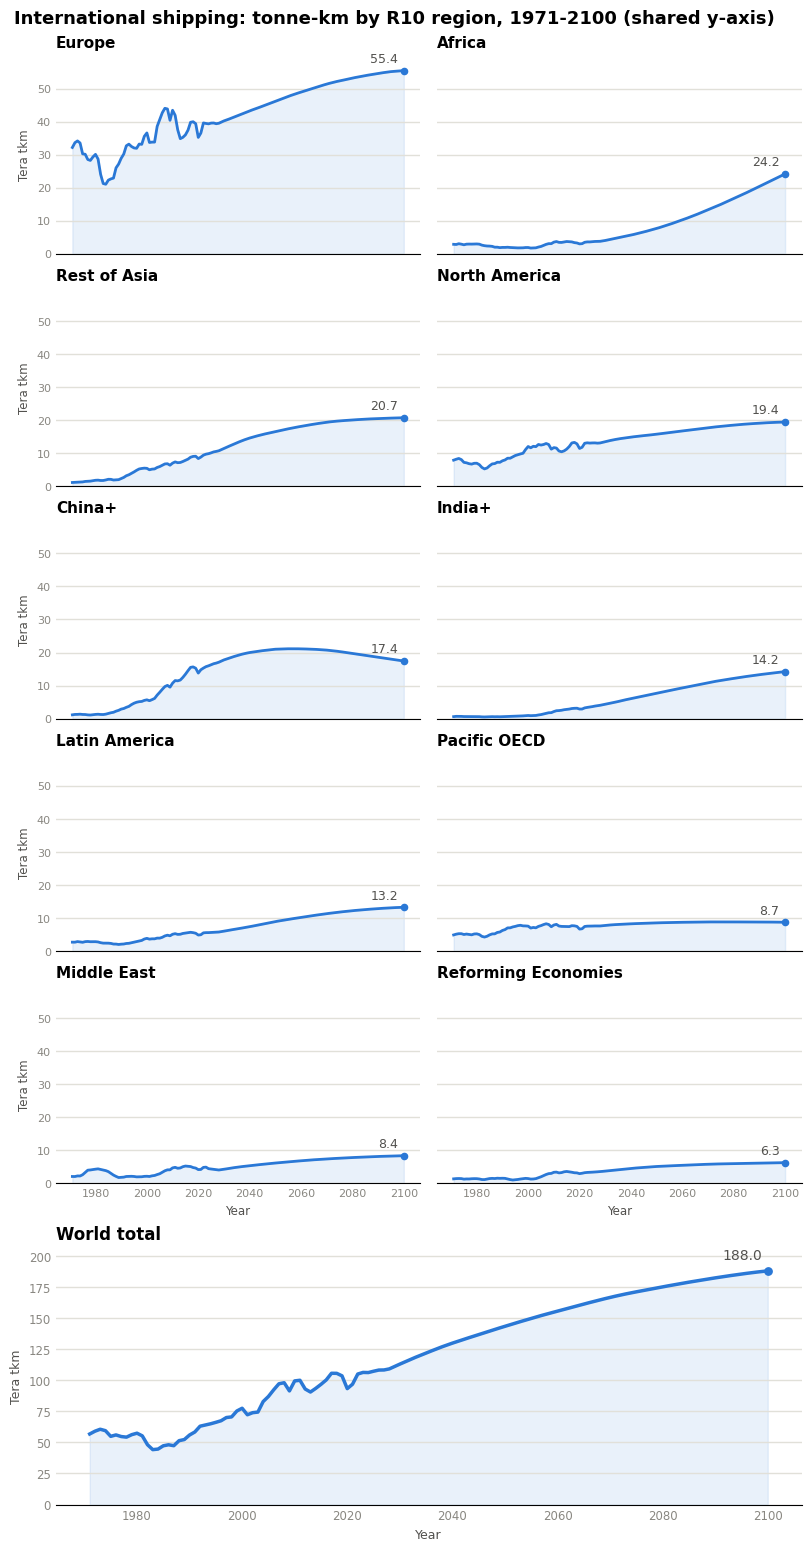

In [6]:
SERIES_COLOR = "#2a78d6"

n_regions = len(region_order)
n_cols = 2
n_rows = -(-n_regions // n_cols)  # ceil division

# extra row spanning both columns at the bottom for the world total, given
# more height since it carries its own axis labels
fig = plt.figure(figsize=(4 * n_cols, 2.6 * n_rows + 2.4), constrained_layout=True)
gs = fig.add_gridspec(n_rows + 1, n_cols, height_ratios=[*([1] * n_rows), 1.3])

region_axes = []
for i in range(n_regions):
    row, col = divmod(i, n_cols)
    ref = region_axes[0] if region_axes else None
    ax = fig.add_subplot(gs[row, col], sharex=ref, sharey=ref)
    region_axes.append(ax)

world_ax = fig.add_subplot(gs[n_rows, :], sharex=region_axes[0])

# shared y-axis (Tera tkm) across the region panels, so magnitude differences
# between regions are visible rather than each panel being normalized to its own scale
global_max = (r10_preprocessed / 1e6).max().max()

for i, (ax, region) in enumerate(zip(region_axes, region_order)):
    series = r10_preprocessed[region] / 1e6  # Mega tkm -> Tera tkm (10^12 tkm)
    ax.plot(series.index, series.values, color=SERIES_COLOR, linewidth=2)
    ax.fill_between(series.index, series.values, 0, color=SERIES_COLOR, alpha=0.1)
    ax.scatter([series.index[-1]], [series.values[-1]], color=SERIES_COLOR, s=20, zorder=3)

    ax.set_title(region, fontsize=11, fontweight="bold", loc="left")
    ax.annotate(
        f"{series.values[-1]:.1f}",
        xy=(series.index[-1], series.values[-1]),
        xytext=(-4, 6), textcoords="offset points",
        ha="right", fontsize=9, color="#52514e",
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", linewidth=1)
    ax.tick_params(axis="both", labelsize=8, colors="#898781", length=0)

    # only the left-most panel in each row keeps y tick labels / gets the axis label,
    # since the scale is now shared across every panel
    is_left_col = (i % n_cols) == 0
    if is_left_col:
        ax.set_ylabel("Tera tkm", fontsize=8.5, color="#52514e")
    else:
        ax.tick_params(axis="y", labelleft=False)

    # only the bottom-most panel in each column keeps x tick labels / gets the axis label,
    # so the shared x-axis reads as one aligned axis instead of repeating on every row
    is_bottom_of_column = (i + n_cols) >= n_regions
    if is_bottom_of_column:
        ax.set_xlabel("Year", fontsize=8.5, color="#52514e")
    else:
        ax.tick_params(axis="x", labelbottom=False)

region_axes[0].set_ylim(0, global_max * 1.08)  # shared across every region panel

# --- World total panel, spanning both columns, own scale (it dwarfs any single region) ---
world_total = r10_preprocessed.sum(axis=1) / 1e6
world_ax.plot(world_total.index, world_total.values, color=SERIES_COLOR, linewidth=2.5)
world_ax.fill_between(world_total.index, world_total.values, 0, color=SERIES_COLOR, alpha=0.1)
world_ax.scatter([world_total.index[-1]], [world_total.values[-1]], color=SERIES_COLOR, s=28, zorder=3)
world_ax.set_title("World total", fontsize=12, fontweight="bold", loc="left")
world_ax.annotate(
    f"{world_total.values[-1]:.1f}",
    xy=(world_total.index[-1], world_total.values[-1]),
    xytext=(-4, 8), textcoords="offset points",
    ha="right", fontsize=10, color="#52514e",
)
world_ax.set_ylim(0, world_total.max() * 1.1)
world_ax.set_ylabel("Tera tkm", fontsize=9, color="#52514e")
world_ax.set_xlabel("Year", fontsize=9, color="#52514e")
world_ax.spines["top"].set_visible(False)
world_ax.spines["right"].set_visible(False)
world_ax.spines["left"].set_visible(False)
world_ax.grid(axis="y", color="#e1e0d9", linewidth=1)
world_ax.tick_params(axis="both", labelsize=8.5, colors="#898781", length=0)

fig.suptitle(
    "International shipping: tonne-km by R10 region, 1971-2100 (shared y-axis)",
    fontsize=13, fontweight="bold", x=0.01, ha="left",
)
plt.show()